<a href="https://colab.research.google.com/github/flipreis21/PPEC0039/blob/main/Planejamento_experimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Planejamento de Experimentos Aplicado ao Geoprocessamento
### Delineamentos (DCC, DBC, DQL) e Dimensionamento Amostral

Este notebook é um guia teórico-prático para a aplicação de testes estatísticos na avaliação de dados espaciais, sensores e algoritmos geográficos.

## 1. Inicialização do Ambiente
Vamos importar as bibliotecas essenciais para manipulação de dados e execução das Análises de Variância (ANOVA).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Ambiente SIG/Estatístico inicializado com sucesso!")

Ambiente SIG/Estatístico inicializado com sucesso!


## 2. Delineamento Completamente Casualizado (DCC)

### Base Teórica
O **DCC** é o delineamento mais simples. Ele pressupõe que o ambiente de teste é estritamente homogêneo e que a única fonte de variação nos resultados será o próprio tratamento e o erro aleatório.

Modelo matemático: $y_{ij} = \mu + \tau_i + \epsilon_{ij}$

### Caso Prático no Geoprocessamento
Queremos comparar a precisão (medida pelo Erro Quadrático Médio - RMSE, em metros) de **3 métodos de interpolação espacial** (IDW, Krigagem e Spline). Para garantir a homogeneidade exigida pelo DCC, testamos os algoritmos em uma **área de relevo perfeitamente plano e simulado**, usando 5 conjuntos de pontos de amostragem gerados aleatoriamente.

--- TABELA ANOVA - DCC (Interpolação) ---
                          sum_sq    df          F   PR(>F)
C(Metodo_Interpolacao)  1.557751   2.0  18.420689  0.00022
Residual                0.507392  12.0        NaN      NaN


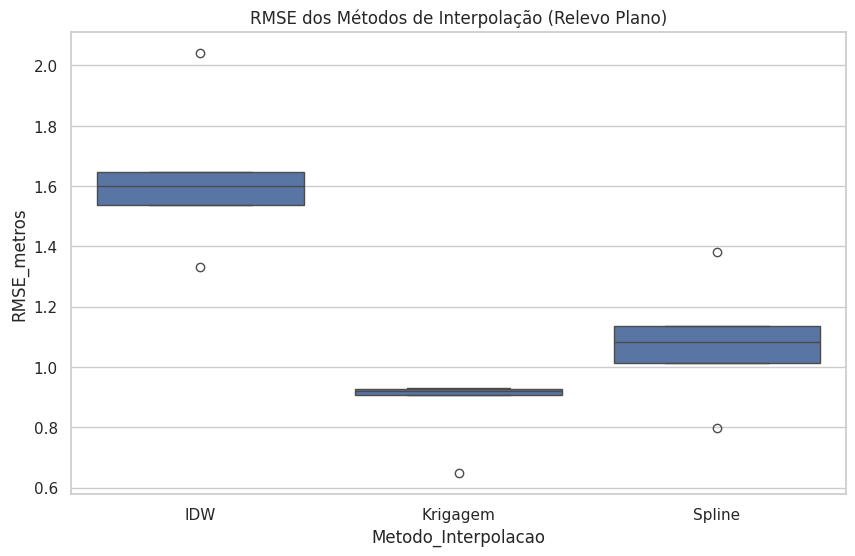

In [3]:
np.random.seed(101)

# 3 Tratamentos (Métodos) x 5 Repetições = 15 observações
metodos = ['IDW', 'Krigagem', 'Spline'] * 5
rmse_base = {'IDW': 1.5, 'Krigagem': 0.8, 'Spline': 1.2}

rmse_valores = [rmse_base[m] + np.random.normal(0, 0.2) for m in metodos]

df_dcc = pd.DataFrame({'Metodo_Interpolacao': metodos, 'RMSE_metros': rmse_valores})

# ANOVA do DCC
modelo_dcc = ols('RMSE_metros ~ C(Metodo_Interpolacao)', data=df_dcc).fit()
anova_dcc = sm.stats.anova_lm(modelo_dcc, typ=2)

print("--- TABELA ANOVA - DCC (Interpolação) ---")
print(anova_dcc)

sns.boxplot(x='Metodo_Interpolacao', y='RMSE_metros', data=df_dcc)
plt.title('RMSE dos Métodos de Interpolação (Relevo Plano)')
plt.show()

## 3. Delineamento em Blocos Casualizados (DBC)

### Base Teórica
Na vida real, a geografia varia. O **DBC** é usado quando temos **uma fonte de heterogeneidade conhecida**. Nós a isolamos na forma de "Blocos" para que ela não infle o erro residual.

Modelo matemático: $y_{ij} = \mu + \tau_i + \beta_j + \epsilon_{ij}$

### Caso Prático no Geoprocessamento
Estamos avaliando a Acurácia Global (%) de **4 classificadores de imagens de satélite** (Random Forest, SVM, MaxEnt, Rede Neural). Como sabemos que a complexidade do terreno afeta a classificação, testamos todos os 4 algoritmos em **3 biomas diferentes** (Amazônia, Cerrado, Caatinga). Aqui, o *Bioma é o Bloco*.

In [4]:
np.random.seed(102)
algoritmos = ['Random_Forest', 'SVM', 'MaxEnt', 'Rede_Neural'] * 3
biomas = sorted(['Amazonia', 'Cerrado', 'Caatinga'] * 4)

acc_base = {'Random_Forest': 88, 'SVM': 82, 'MaxEnt': 79, 'Rede_Neural': 91}
efeito_bioma = {'Amazonia': -5, 'Cerrado': 0, 'Caatinga': 2} # Floresta densa reduz acurácia

acc_valores = [acc_base[a] + efeito_bioma[b] + np.random.normal(0, 1.5) for a, b in zip(algoritmos, biomas)]

df_dbc = pd.DataFrame({'Algoritmo': algoritmos, 'Bioma_Bloco': biomas, 'Acuracia_Global': acc_valores})

# ANOVA do DBC
modelo_dbc = ols('Acuracia_Global ~ C(Algoritmo) + C(Bioma_Bloco)', data=df_dbc).fit()
anova_dbc = sm.stats.anova_lm(modelo_dbc, typ=2)

print("--- TABELA ANOVA - DBC (Classificação de Imagens) ---")
print(anova_dbc)

--- TABELA ANOVA - DBC (Classificação de Imagens) ---
                    sum_sq   df          F    PR(>F)
C(Algoritmo)    254.348534  3.0  30.741814  0.000487
C(Bioma_Bloco)   73.842878  2.0  13.387520  0.006135
Residual         16.547399  6.0        NaN       NaN


## 4. Delineamento em Quadrado Latino (DQL)

### Base Teórica
Usado para controlar **duas fontes de variação ortogonais simultâneas**. A restrição é que Número de Tratamentos = Linhas = Colunas ($r \times r$).

### Caso Prático no Geoprocessamento
Queremos testar a precisão de posicionamento (Erro Posicional em metros) de **4 receptores GNSS/GPS** (Tratamentos: Trimble, Garmin, Leica, Topcon).
A área de estudo tem dois grandes gradientes que afetam o sinal:
1. **Densidade de Dossel / Cobertura Vegetal** (Linhas: Aberto, Ralo, Denso, Fechado)
2. **Declividade do Terreno** (Colunas: Plano, Ondulado, Forte_Ondulado, Montanhoso)

In [5]:
# Quadrado Latino 4x4
arranjo_dql = [
    ['Trimble', 'Garmin', 'Leica', 'Topcon'],
    ['Garmin', 'Leica', 'Topcon', 'Trimble'],
    ['Leica', 'Topcon', 'Trimble', 'Garmin'],
    ['Topcon', 'Trimble', 'Garmin', 'Leica']
]

dossel = ['Aberto', 'Ralo', 'Denso', 'Fechado']
declividade = ['Plano', 'Ondulado', 'Forte', 'Montanhoso']

dados_dql = []
base_erro = {'Trimble': 1.0, 'Garmin': 3.5, 'Leica': 0.8, 'Topcon': 1.2}

for i in range(4):
    for j in range(4):
        gps = arranjo_dql[i][j]
        # Dossel fechado (+ erro) e Montanha (+ erro multipath)
        erro_simulado = base_erro[gps] + (i * 0.8) + (j * 0.5) + np.random.normal(0, 0.3)
        dados_dql.append({'GPS': gps, 'Dossel': dossel[i], 'Declividade': declividade[j], 'Erro_Metros': erro_simulado})

df_dql = pd.DataFrame(dados_dql)

# ANOVA do DQL
modelo_dql = ols('Erro_Metros ~ C(Dossel) + C(Declividade) + C(GPS)', data=df_dql).fit()
anova_dql = sm.stats.anova_lm(modelo_dql, typ=2)

print("--- TABELA ANOVA - DQL (Precisão GNSS) ---")
print(anova_dql)

--- TABELA ANOVA - DQL (Precisão GNSS) ---
                   sum_sq   df           F        PR(>F)
C(Dossel)       13.565405  3.0  288.424285  7.125490e-07
C(Declividade)   5.087213  3.0  108.163061  1.300027e-05
C(GPS)          12.418519  3.0  264.039474  9.267698e-07
Residual         0.094066  6.0         NaN           NaN


## 5. Eficiência e Dimensionamento Amostral
O **Coeficiente de Variação (CV%)** mede a qualidade geral do teste. Variáveis espaciais tendem a ter maior variação natural. O cálculo do poder amostral nos diz quantas coletas em campo precisamos fazer para provar estatisticamente que um mapa ou sensor é melhor que outro.

In [6]:
def calcular_cv(modelo, df, coluna_resposta):
    qm_res = modelo.mse_resid
    media = df[coluna_resposta].mean()
    return (np.sqrt(qm_res) / media) * 100

print(f"CV% do DCC (Interpolação): {calcular_cv(modelo_dcc, df_dcc, 'RMSE_metros'):.2f}%")
print(f"CV% do DBC (Biomas): {calcular_cv(modelo_dbc, df_dbc, 'Acuracia_Global'):.2f}%")
print(f"CV% do DQL (Receptores GPS): {calcular_cv(modelo_dql, df_dql, 'Erro_Metros'):.2f}%")

def amostras_necessarias(s_resid, diff_minima, alpha=0.05, poder=0.80):
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta = stats.norm.ppf(poder)
    r = 2 * ((z_alpha + z_beta) * s_resid / diff_minima)**2
    return int(np.ceil(r))

s_estimado = np.sqrt(modelo_dcc.mse_resid) # Usando o desvio do DCC como base
diff_detectar = 0.5 # Quero conseguir provar que um mapa é 0.5m melhor que o outro

print(f"\nPara detectar uma melhoria de {diff_detectar}m no RMSE com 80% de poder estatístico:")
print(f"-> Serão necessárias {amostras_necessarias(s_estimado, diff_detectar)} amostras por método de interpolação.")

CV% do DCC (Interpolação): 17.23%
CV% do DBC (Biomas): 1.97%
CV% do DQL (Receptores GPS): 3.57%

Para detectar uma melhoria de 0.5m no RMSE com 80% de poder estatístico:
-> Serão necessárias 3 amostras por método de interpolação.
